In [ ]:
# ======================
# 1. MOUNT
# ======================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ======================
# 2. IMPORTS
# ======================
import os, cv2, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt
from glob import glob

!pip install -q albumentations
import albumentations as A

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# ======================
# 3. PATHS
# ======================
BASE = "/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv"

TRAIN_IMG  = os.path.join(BASE, "train/images")
TRAIN_MASK = os.path.join(BASE, "train/masks")
VAL_IMG    = os.path.join(BASE, "val/images")
VAL_MASK   = os.path.join(BASE, "val/masks")
TEST_IMG   = os.path.join(BASE, "test/images")
TEST_MASK  = os.path.join(BASE, "test/masks")

for p in [TRAIN_IMG, TRAIN_MASK, VAL_IMG, VAL_MASK, TEST_IMG, TEST_MASK]:
    print(p, os.path.exists(p))

/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/train/images True
/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/train/masks True
/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/val/images True
/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/val/masks True
/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/test/images True
/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/test/masks True


In [ ]:
# ======================
# 4. CONFIG
# ======================
IMG_SIZE    = 256
BATCH       = 8
EPOCHS_P1   = 30
EPOCHS_P2   = 40
TARGET_DICE = 0.90

In [ ]:

# ======================
# 5. LOAD FILES
# ======================
train_imgs  = sorted(glob(TRAIN_IMG  + "/*"))
train_masks = sorted(glob(TRAIN_MASK + "/*"))
val_imgs    = sorted(glob(VAL_IMG    + "/*"))
val_masks   = sorted(glob(VAL_MASK   + "/*"))
test_imgs   = sorted(glob(TEST_IMG   + "/*"))
test_masks  = sorted(glob(TEST_MASK  + "/*"))

print(f"Train: {len(train_imgs)}  Val: {len(val_imgs)}  Test: {len(test_imgs)}")


Train: 3837  Val: 477  Test: 479


In [ ]:
# ======================
# 6. AUGMENTATION
# ======================
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.3),
    A.GridDistortion(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(5, 25), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, fill_value=0, p=0.3),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_10960/774933237.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 25), p=0.3),
/tmp/ipykernel_10960/774933237.py:13: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, fill_value=0, p=0.3),


In [ ]:
# ======================
# 7. PREPROCESS
# ======================
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    clahe = cv2.createCLAHE(2.0, (8, 8))
    img = clahe.apply(img)
    img = img.astype(np.float32) / 255.0
    return np.stack([img, img, img], axis=-1)

def load_mask(path):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    m = cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    m = (m > 200).astype(np.float32)
    return np.expand_dims(m, -1)

def load_and_augment(img_path, mask_path):
    img     = load_image(img_path.numpy().decode())
    mask    = load_mask(mask_path.numpy().decode())
    mask_2d = mask[:, :, 0]

    img_u8   = (img * 255).astype(np.uint8)
    mask_u8  = (mask_2d * 255).astype(np.uint8)

    aug      = aug_pipeline(image=img_u8, mask=mask_u8)
    img_out  = aug["image"].astype(np.float32) / 255.0
    mask_out = (aug["mask"] > 127).astype(np.float32)

    return img_out, np.expand_dims(mask_out, -1)

def load_only(img_path, mask_path):
    return load_image(img_path.numpy().decode()), load_mask(mask_path.numpy().decode())

def parse_train(i, m):
    img, mask = tf.py_function(load_and_augment, [i, m], [tf.float32, tf.float32])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

def parse_val(i, m):
    img, mask = tf.py_function(load_only, [i, m], [tf.float32, tf.float32])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

In [ ]:
# ======================
# 8. DATASET
# ======================
def build(imgs, masks, train=True):
    ds = tf.data.Dataset.from_tensor_slices((imgs, masks))
    if train: ds = ds.shuffle(len(imgs))
    ds = ds.map(parse_train if train else parse_val, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds = build(train_imgs, train_masks, True)
val_ds   = build(val_imgs,   val_masks,   False)
test_ds  = build(test_imgs,  test_masks,  False)

In [ ]:
# ======================
# 9. LOSS + METRIC
# ======================
def tversky(y_true, y_pred):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    tp = tf.reduce_sum(y_true * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    return (tp + 1e-6) / (tp + 0.7*fn + 0.3*fp + 1e-6)

def focal_tversky(y_true, y_pred):
    return tf.pow(1 - tversky(y_true, y_pred), 0.75)

def dice_metric(y_true, y_pred):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    inter  = tf.reduce_sum(y_true * y_pred)
    return (2*inter + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.6 * focal_tversky(y_true, y_pred) + 0.4 * tf.reduce_mean(bce)

In [ ]:
# ======================
# 10. ATTENTION GATE
# ======================
def attention_gate(x, g, f):
    wx  = tf.keras.layers.Conv2D(f, 1, padding="same")(x)
    wg  = tf.keras.layers.Conv2D(f, 1, padding="same")(g)
    psi = tf.keras.layers.Activation("relu")(tf.keras.layers.Add()([wx, wg]))
    psi = tf.keras.layers.Conv2D(1, 1, padding="same")(psi)
    psi = tf.keras.layers.Activation("sigmoid")(psi)
    return tf.keras.layers.Multiply()([x, psi])


In [ ]:
# ======================
# 11. DECODER BLOCK
# ======================
def decoder_block(x, skip, f):
    x    = tf.keras.layers.Conv2DTranspose(f, 2, 2)(x)
    skip = attention_gate(skip, x, f // 2)
    x    = tf.keras.layers.Concatenate()([x, skip])
    x    = tf.keras.layers.Conv2D(f, 3, padding="same")(x)
    x    = tf.keras.layers.BatchNormalization()(x)
    x    = tf.keras.layers.Activation("relu")(x)
    x    = tf.keras.layers.Conv2D(f, 3, padding="same")(x)
    x    = tf.keras.layers.BatchNormalization()(x)
    x    = tf.keras.layers.Activation("relu")(x)
    return x

In [ ]:
# ======================
# 12. BUILD MODEL
# ======================
def build_model():
    inp = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))

    backbone = tf.keras.applications.EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_tensor=inp
    )

    s1     = backbone.get_layer("block2a_expand_activation").output  # 128x128
    s2     = backbone.get_layer("block3a_expand_activation").output  # 64x64
    s3     = backbone.get_layer("block4a_expand_activation").output  # 32x32
    s4     = backbone.get_layer("block6a_expand_activation").output  # 16x16
    bridge = backbone.get_layer("top_activation").output              # 8x8

    d1 = decoder_block(bridge, s4, 256)
    d2 = decoder_block(d1,     s3, 128)
    d3 = decoder_block(d2,     s2, 64)
    d4 = decoder_block(d3,     s1, 32)

    x   = tf.keras.layers.Conv2DTranspose(16, 2, 2)(d4)
    x   = tf.keras.layers.Conv2D(16, 3, padding="same")(x)
    x   = tf.keras.layers.BatchNormalization()(x)
    x   = tf.keras.layers.Activation("relu")(x)
    out = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(x)

    model = tf.keras.Model(inp, out)
    return model, backbone

model, backbone = build_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 256, 256,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 256, 256,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │      1,152 │ block1a_se_excit

 Total params: 24,205,380 (92.34 MB)

 Trainable params: 24,078,221 (91.85 MB)

 Non-trainable params: 127,159 (496.72 KB)

In [ ]:
# ======================
# 13. PHASE 1 — ENCODER FROZEN
# ======================
print("\n*** PHASE 1: Encoder frozen ***")
backbone.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=combined_loss,
    metrics=[dice_metric]
)

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint("best_p1.keras", monitor="val_dice_metric", mode="max", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_dice_metric", mode="max", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_dice_metric", mode="max", factor=0.5, patience=4, min_lr=1e-6)
]

hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1
)

best_p1 = max(hist1.history["val_dice_metric"])
print(f"Phase 1 Best Dice: {best_p1:.4f}")


*** PHASE 1: Encoder frozen ***
Epoch 1/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 638s 1s/step - dice_metric: 0.2713 - loss: 0.4950 - val_dice_metric: 0.1143 - val_loss: 0.9077 - learning_rate: 0.0010
Epoch 2/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - dice_metric: 0.4806 - loss: 0.3845 - val_dice_metric: 0.4316 - val_loss: 0.3965 - learning_rate: 0.0010
Epoch 3/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 39s 81ms/step - dice_metric: 0.5230 - loss: 0.3637 - val_dice_metric: 0.4558 - val_loss: 0.4063 - learning_rate: 0.0010
Epoch 4/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - dice_metric: 0.5511 - loss: 0.3469 - val_dice_metric: 0.2377 - val_loss: 0.5530 - learning_rate: 0.0010
Epoch 5/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 37s 77ms/step - dice_metric: 0.5662 - loss: 0.3379 - val_dice_metric: 0.4253 - val_loss: 0.4029 - learning_rate: 0.0010
Epoch 6/30
480/480 ━━━━━━━━━━━━━━━━━━━━ 39s 81ms/step - dice_metric: 0.5804 - loss: 0.3296 - val_dice_metric: 0.4899 - val_loss: 0.3980 - learning_rate: 0.0010
Epoch 7/

In [ ]:
# ======================
# 14. PHASE 2 — FULL FINE-TUNE
# ======================
print("\n*** PHASE 2: Full fine-tune ***")
backbone.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[dice_metric]
)

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint("best_p2.keras", monitor="val_dice_metric", mode="max", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_dice_metric", mode="max", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_dice_metric", mode="max", factor=0.5, patience=5, min_lr=1e-7)
]

hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2
)

best_p2 = max(hist2.history["val_dice_metric"])
print(f"Phase 2 Best Dice: {best_p2:.4f}")


*** PHASE 2: Full fine-tune ***
Epoch 1/40
480/480 ━━━━━━━━━━━━━━━━━━━━ 344s 361ms/step - dice_metric: 0.5039 - loss: 0.3676 - val_dice_metric: 0.4981 - val_loss: 0.3973 - learning_rate: 1.0000e-04
Epoch 2/40
480/480 ━━━━━━━━━━━━━━━━━━━━ 59s 122ms/step - dice_metric: 0.7211 - loss: 0.2339 - val_dice_metric: 0.7390 - val_loss: 0.2105 - learning_rate: 1.0000e-04
Epoch 3/40
480/480 ━━━━━━━━━━━━━━━━━━━━ 59s 122ms/step - dice_metric: 0.7581 - loss: 0.2085 - val_dice_metric: 0.7454 - val_loss: 0.2335 - learning_rate: 1.0000e-04
Epoch 4/40
480/480 ━━━━━━━━━━━━━━━━━━━━ 56s 116ms/step - dice_metric: 0.7665 - loss: 0.2004 - val_dice_metric: 0.7118 - val_loss: 0.2413 - learning_rate: 1.0000e-04
Epoch 5/40
480/480 ━━━━━━━━━━━━━━━━━━━━ 59s 122ms/step - dice_metric: 0.7825 - loss: 0.1892 - val_dice_metric: 0.8121 - val_loss: 0.1634 - learning_rate: 1.0000e-04
Epoch 6/40
480/480 ━━━━━━━━━━━━━━━━━━━━ 59s 123ms/step - dice_metric: 0.7910 - loss: 0.1832 - val_dice_metric: 0.8374 - val_loss: 0.1506 - le

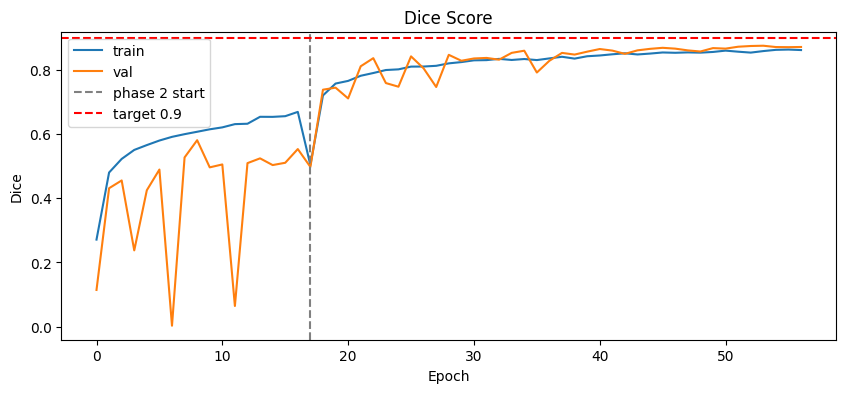

In [ ]:
# ======================
# 15. GRAPH
# ======================
all_dice     = hist1.history["dice_metric"]     + hist2.history["dice_metric"]
all_val_dice = hist1.history["val_dice_metric"] + hist2.history["val_dice_metric"]

plt.figure(figsize=(10, 4))
plt.plot(all_dice,     label="train")
plt.plot(all_val_dice, label="val")
plt.axvline(len(hist1.history["dice_metric"]), color="gray", linestyle="--", label="phase 2 start")
plt.axhline(TARGET_DICE, color="red", linestyle="--", label=f"target {TARGET_DICE}")
plt.legend(); plt.title("Dice Score"); plt.xlabel("Epoch"); plt.ylabel("Dice")
plt.show()

60/60 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - dice_metric: 0.8798 - loss: 0.1162
Test Dice: 0.8798
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


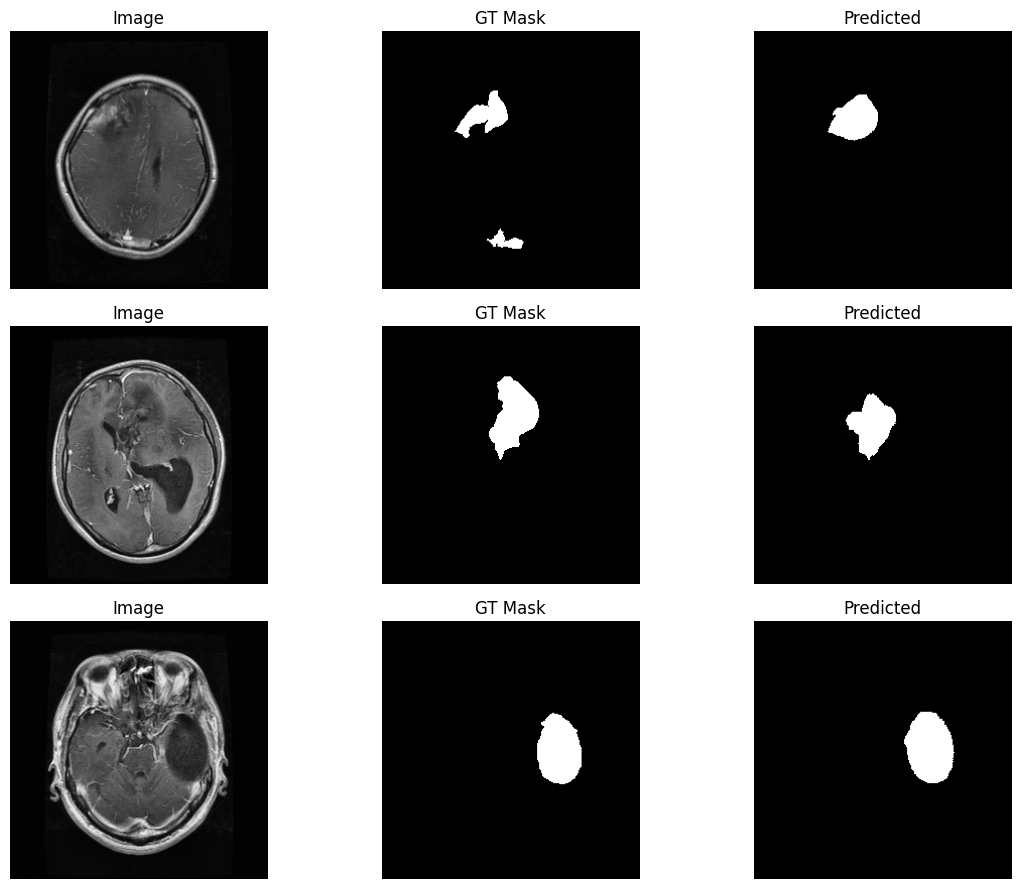

In [ ]:
# ======================
# 16. TEST
# ======================
res = model.evaluate(test_ds)
print(f"Test Dice: {res[1]:.4f}")

for imgs, masks in test_ds.take(1):
    preds = model.predict(imgs)
    preds = (preds > 0.5).astype(np.float32)
    plt.figure(figsize=(12, 9))
    for i in range(3):
        img_disp = imgs[i].numpy()[:, :, 0]
        plt.subplot(3, 3, i*3+1); plt.imshow(img_disp,                   cmap="gray"); plt.title("Image");     plt.axis("off")
        plt.subplot(3, 3, i*3+2); plt.imshow(masks[i].numpy().squeeze(),  cmap="gray"); plt.title("GT Mask");   plt.axis("off")
        plt.subplot(3, 3, i*3+3); plt.imshow(preds[i].squeeze(),          cmap="gray"); plt.title("Predicted"); plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# ======================
# 17. SAVE
# ======================
SAVE_DIR = "/content/drive/MyDrive/Project work/models/new Segmentation"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(os.path.join(SAVE_DIR, "brisc_effunet.keras"))
model.save(os.path.join(SAVE_DIR, "brisc_effunet.h5"))
print("Model saved.")

Model saved.
